# Обзор результатов

Здесь я смотрю уже готовые логи экспериментов. Сравнение идёт между FP32, FP64 и FP16 для `heat1d`, `burgers1d`, `helmholtz1d` и `convection1d`.

Плохие seed не скрывались. FP16 вынесен отдельно, потому что он часто даёт плохие или невалидные метрики.

In [17]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)

root = Path.cwd().resolve()
for p in [root] + list(root.parents):
    if (p / "report_results" / "tables" / "report_cases.csv").exists():
        root = p
        break

table_dir = root / "report_results" / "tables"
fig_dir = root / "report_results" / "figures"
rerun_dir = root / "report_results" / "rerun_plan"

runs = pd.read_csv(table_dir / "all_runs_normalized.csv")
quality = pd.read_csv(table_dir / "run_quality.csv")
overview = pd.read_csv(table_dir / "task_overview.csv")
comp = pd.read_csv(table_dir / "fp32_fp64_comparison.csv")
fp16 = pd.read_csv(table_dir / "fp16_summary.csv")
report_cases = pd.read_csv(table_dir / "report_cases.csv")

## 1. Все найденные запуски

Сначала общий счётчик по всем run-папкам и краткая таблица по задачам, параметрам и dtype.

In [18]:
summary = pd.DataFrame([
    ["всего run-папок", len(runs)],
    ["валидных запусков", int(runs["is_valid"].sum())],
    ["плохих или нестабильных", int(runs["is_bad"].sum())],
    ["задачи", ", ".join(sorted(runs["task_name"].dropna().unique()))],
    ["dtype", ", ".join(sorted(runs["dtype"].dropna().unique()))],
], columns=["что", "значение"])
display(summary)

cols = ["task_name", "main_parameter_name", "main_parameter_value", "dtype", "n_total", "n_valid", "n_bad", "median_best_l2", "bad_rate"]
display(overview[cols].sort_values(["task_name", "main_parameter_value", "dtype"]).head(80))

,что,значение
0,всего run-папок,439
1,валидных запусков,415
2,плохих или нестабильных,240
3,задачи,"burgers1d, convection1d, heat1d, helmholtz1d"
4,dtype,"fp16, fp32, fp64"


,task_name,main_parameter_name,main_parameter_value,dtype,n_total,n_valid,n_bad,median_best_l2,bad_rate
0,burgers1d,nu,0.0001,fp32,2,1,2,0.391018,1.000000
1,burgers1d,nu,0.0001,fp64,2,2,2,0.413677,1.000000
2,burgers1d,nu,0.0002,fp32,2,2,2,0.397256,1.000000
3,burgers1d,nu,0.0002,fp64,2,2,2,0.408756,1.000000
4,burgers1d,nu,0.0005,fp32,2,2,2,0.385514,1.000000
5,burgers1d,nu,0.0005,fp64,2,2,2,0.383942,1.000000
6,burgers1d,nu,0.0010,fp16,2,0,2,NaN,1.000000
7,burgers1d,nu,0.0010,fp32,16,15,13,0.230167,0.812500
8,burgers1d,nu,0.0010,fp64,16,16,9,0.232790,0.562500
9,burgers1d,nu,0.0020,fp16,2,0,2,NaN,1.000000


Эта таблица нужна, чтобы было видно, что отчёт собирается не только из последней папки, а из всех найденных run-папок.

## 2. Heat как sanity check

Heat - простая проверочная задача. Если здесь ошибки маленькие, значит базовый пайплайн обучения и подсчёта метрик работает адекватно.

In [19]:
heat = overview[overview["task_name"] == "heat1d"].copy()
heat = heat[["main_parameter_name", "main_parameter_value", "dtype", "n_total", "n_valid", "n_bad", "median_best_l2", "bad_rate"]]
display(heat.sort_values(["main_parameter_value", "dtype"]))

,main_parameter_name,main_parameter_value,dtype,n_total,n_valid,n_bad,median_best_l2,bad_rate
26,alpha,0.1,fp32,3,3,0,0.000375,0.0
27,alpha,0.1,fp64,3,3,0,0.000311,0.0


На Heat разница между FP32 и FP64 небольшая. Я использую это как sanity check, а не как главный аргумент про преимущество FP64.

## 3. Burgers

Для Burgers есть несколько разных запусков: обычные `nu`, low-nu, long LBFGS и проверки learning rate. Ниже показаны все найденные сравнимые FP32/FP64 группы.

In [20]:
label_names = {
    "stable_positive": "FP64 заметно лучше",
    "moderate_positive": "FP64 немного лучше",
    "similar": "похоже",
    "fp32_better": "FP32 лучше",
    "seed_sensitive": "зависит от seed",
    "fp16_failure": "FP16 нестабилен",
    "sanity_check": "простая проверка",
    "stable_fp64_better": "FP64 заметно лучше",
    "moderate_fp64_better": "FP64 немного лучше",
    "single_seed_hard_case": "один seed, нужна проверка",
    "insufficient_data": "не хватает данных",
}

burgers = comp[comp["task_name"] == "burgers1d"].copy()
cols = [
    "main_parameter_value", "variant", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate", "conclusion",
]
burgers = burgers[cols].sort_values(["main_parameter_value", "variant"])
burgers["conclusion"] = burgers["conclusion"].map(lambda x: label_names.get(str(x), x))
burgers = burgers.rename(columns={
    "main_parameter_value": "nu",
    "variant": "вариант",
    "fp32_n_valid": "FP32 valid",
    "fp64_n_valid": "FP64 valid",
    "fp32_median_best_l2": "FP32 median L2",
    "fp64_median_best_l2": "FP64 median L2",
    "fp64_over_fp32_median": "FP64/FP32",
    "fp32_bad_rate": "FP32 bad rate",
    "fp64_bad_rate": "FP64 bad rate",
    "conclusion": "вывод",
})
display(burgers)

,nu,вариант,FP32 valid,FP64 valid,FP32 median L2,FP64 median L2,FP64/FP32,FP32 bad rate,FP64 bad rate,вывод
11,0.0001,burgers_hard_nu_0p0001,1,2,0.391018,0.413677,1.057949,1.0,1.0,зависит от seed
12,0.0002,burgers_hard_nu_0p0002,2,2,0.397256,0.408756,1.028948,1.0,1.0,зависит от seed
13,0.0005,burgers_hard_nu_0p0005,2,2,0.385514,0.383942,0.995923,1.0,1.0,зависит от seed
0,0.0010,adam1e4_lbfgs05_steps2000_inner5_resample200,1,1,0.176781,0.185780,1.050904,0.0,0.0,зависит от seed
1,0.0010,adam1e4_lbfgs1_steps2000_inner5_resample200,1,1,0.220319,0.178767,0.811399,1.0,0.0,зависит от seed
2,0.0010,adam2e4_lbfgs05_steps2000_inner5_resample200,1,1,0.226545,0.230192,1.016099,1.0,1.0,зависит от seed
3,0.0010,adam2e4_lbfgs1_steps2000_inner5_resample200,1,1,0.225579,0.267399,1.185391,1.0,1.0,зависит от seed
4,0.0010,adam3000_lbfgs5000_inner5_resample200,1,1,0.270881,0.099582,0.367622,1.0,0.0,зависит от seed
7,0.0010,adam5e4_lbfgs05_steps2000_inner5_resample200,1,1,0.233625,0.078599,0.336433,1.0,0.0,зависит от seed
9,0.0010,adam5e4_lbfgs1_steps2000_inner5_resample200,1,1,0.270881,0.099582,0.367622,1.0,0.0,зависит от seed


Burgers не даёт чистой истории, что FP64 всегда лучше. На части запусков результаты близкие, на части FP32 лучше. Поэтому Burgers лучше использовать как отрицательный или смешанный результат.

## 4. Helmholtz

Для Helmholtz запусков больше всего. Тут важно не выбирать лучший seed, а смотреть медиану, число seed и bad rate.

In [21]:
helm = comp[comp["task_name"] == "helmholtz1d"].copy()
helm = helm[helm["main_parameter_value"].isin([5, 7, 8, 10, 12, 15])]
cols = [
    "main_parameter_value", "variant", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate", "conclusion",
]
helm = helm[cols].sort_values(["main_parameter_value", "variant"])
helm["conclusion"] = helm["conclusion"].map(lambda x: label_names.get(str(x), x))
helm = helm.rename(columns={
    "main_parameter_value": "m",
    "variant": "вариант",
    "fp32_n_valid": "FP32 valid",
    "fp64_n_valid": "FP64 valid",
    "fp32_median_best_l2": "FP32 median L2",
    "fp64_median_best_l2": "FP64 median L2",
    "fp64_over_fp32_median": "FP64/FP32",
    "fp32_bad_rate": "FP32 bad rate",
    "fp64_bad_rate": "FP64 bad rate",
    "conclusion": "вывод",
})
display(helm.head(80))

,m,вариант,FP32 valid,FP64 valid,FP32 median L2,FP64 median L2,FP64/FP32,FP32 bad rate,FP64 bad rate,вывод
66,5.0,helmholtz_m5,2,2,0.000082,0.000059,0.721432,0.0,0.0,FP64 немного лучше
67,5.0,helmholtz_m5,2,2,0.001769,0.000634,0.358395,0.0,0.0,FP64 заметно лучше
76,5.0,helmholtz_rs_m5,2,2,0.000150,0.000478,3.181760,0.0,0.0,FP32 лучше
78,7.0,helmholtz_rs_m7,2,2,0.001348,0.000514,0.381523,0.0,0.0,FP64 заметно лучше
37,8.0,adam_only,2,2,0.249723,0.180629,0.723317,0.5,0.5,зависит от seed
...,...,...,...,...,...,...,...,...,...,...
121,12.0,width128_adam2e4_lbfgs05_steps1000_inner10_resample250,1,1,0.044969,0.007474,0.166209,0.0,0.0,зависит от seed
122,12.0,width128_adam2e4_lbfgs1_steps1000_inner10_resample250,1,1,0.056047,0.005652,0.100844,0.0,0.0,зависит от seed
123,12.0,width128_adam5e4_lbfgs05_steps1000_inner10_resample250,1,1,0.004136,0.000170,0.041071,0.0,0.0,зависит от seed
124,12.0,width128_adam5e4_lbfgs1_steps1000_inner10_resample250,1,1,0.019252,0.001540,0.080010,0.0,0.0,зависит от seed


Главный устойчивый положительный кейс - Helmholtz m=12. Там есть по два валидных seed для FP32 и FP64, а медиана FP64 заметно ниже. Helmholtz m=8 выглядит эффектно, но он seed-sensitive, поэтому я не использую его как главный аргумент.

## 5. Convection

Для Convection важно разделять beta=30 и beta=50. Beta=30 аккуратнее, потому что там есть по два seed. Beta=50 выглядит сильным hard-case, но там мало seed.

In [22]:
conv = comp[comp["task_name"] == "convection1d"].copy()
cols = [
    "main_parameter_value", "variant", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate", "conclusion",
]
conv = conv[cols].sort_values(["main_parameter_value", "variant"])
conv["conclusion"] = conv["conclusion"].map(lambda x: label_names.get(str(x), x))
conv = conv.rename(columns={
    "main_parameter_value": "beta",
    "variant": "вариант",
    "fp32_n_valid": "FP32 valid",
    "fp64_n_valid": "FP64 valid",
    "fp32_median_best_l2": "FP32 median L2",
    "fp64_median_best_l2": "FP64 median L2",
    "fp64_over_fp32_median": "FP64/FP32",
    "fp32_bad_rate": "FP32 bad rate",
    "fp64_bad_rate": "FP64 bad rate",
    "conclusion": "вывод",
})
display(conv)

,beta,вариант,FP32 valid,FP64 valid,FP32 median L2,FP64 median L2,FP64/FP32,FP32 bad rate,FP64 bad rate,вывод
25,30.0,convection_beta30,2,2,1.000190,0.007463,0.007462,1.0,0.0,зависит от seed
26,30.0,convection_beta30_lbfgs_grid,2,2,0.010941,0.006625,0.605541,0.0,0.0,FP64 немного лучше
29,30.0,lbfgs_grid_t4,1,1,0.006611,0.010181,1.539935,0.0,0.0,зависит от seed
27,50.0,convection_beta50,1,1,0.741242,0.700409,0.944913,1.0,1.0,зависит от seed
28,50.0,convection_beta50_wide_lbfgs,1,1,0.687307,0.007182,0.010449,1.0,0.0,"один seed, нужна проверка"
30,50.0,lbfgs_grid_t4,1,1,0.850583,0.858125,1.008867,1.0,1.0,зависит от seed


Convection beta=50 выглядит как сильный пример, но здесь мало seed. FP32 мог не сойтись из-за неудачного старта, поэтому я не использую этот кейс как главный устойчивый вывод без дополнительной проверки.

## 6. FP16

FP16 я не смешиваю с основной таблицей FP32/FP64. Здесь это скорее отдельный блок про нестабильность.

In [23]:
reason_names = {
    "runtime_error": "ошибка запуска",
    "nan_metric": "NaN в метриках",
    "inf_metric": "inf в метриках",
    "high_best_l2": "большая best L2",
    "high_final_l2": "большая final L2",
    "missing_metrics": "нет метрик",
    "ok": "без явной ошибки",
}
view = fp16.copy()
view["typical_failure_reason"] = view["typical_failure_reason"].map(lambda x: reason_names.get(str(x), x))
view = view[["task_name", "main_parameter_name", "main_parameter_value", "variant", "n_total", "n_valid", "n_bad", "bad_rate", "typical_failure_reason"]]
view = view.rename(columns={
    "task_name": "задача",
    "main_parameter_name": "параметр",
    "main_parameter_value": "значение",
    "variant": "вариант",
    "n_total": "всего",
    "n_valid": "валидных",
    "n_bad": "плохих",
    "bad_rate": "доля плохих",
    "typical_failure_reason": "типичная причина",
})
display(view)

,задача,параметр,значение,вариант,всего,валидных,плохих,доля плохих,типичная причина
0,burgers1d,nu,NaN,burgers_main_nu0p001,2,0,2,1.0,ошибка запуска
1,burgers1d,nu,NaN,burgers_main_nu0p002,2,0,2,1.0,ошибка запуска
2,burgers1d,nu,0.001,burgers_more_points,2,0,2,1.0,NaN в метриках
3,burgers1d,nu,0.002,burgers_more_points,2,0,2,1.0,NaN в метриках
4,convection1d,beta,NaN,convection_beta30_beta30p0,2,0,2,1.0,ошибка запуска
5,convection1d,beta,30.000,convection_beta30_lbfgs_grid,2,1,2,1.0,большая best L2
6,convection1d,beta,NaN,convection_beta50_beta50p0,1,0,1,1.0,ошибка запуска
7,convection1d,beta,50.000,convection_beta50_wide_lbfgs,1,0,1,1.0,NaN в метриках
8,helmholtz1d,m,NaN,helmholtz_main_m12,2,0,2,1.0,ошибка запуска
9,helmholtz1d,m,NaN,helmholtz_main_m8,2,0,2,1.0,ошибка запуска


FP16 в этих экспериментах скорее показывает режим неудачных запусков, чем полноценный стабильный вариант для сравнения.

## 7. Итоговые кейсы для отчёта

Это главная таблица для отчёта. В неё входят устойчивые положительные кейсы, смешанные/отрицательные примеры, sanity check и отдельный FP16-блок.

In [24]:
show = report_cases.copy()
show["label"] = show["label"].map(lambda x: label_names.get(str(x), x))
show = show[[
    "case_id", "task", "parameter", "variant", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio",
    "bad_rate_fp32", "bad_rate_fp64", "label", "status", "comment",
]]
show = show.rename(columns={
    "case_id": "кейс",
    "task": "задача",
    "parameter": "параметр",
    "variant": "вариант",
    "n_seed_fp32": "FP32 seed",
    "n_seed_fp64": "FP64 seed",
    "fp32_median_best_l2": "FP32 median L2",
    "fp64_median_best_l2": "FP64 median L2",
    "ratio": "FP64/FP32",
    "bad_rate_fp32": "FP32 bad rate",
    "bad_rate_fp64": "FP64 bad rate",
    "label": "тип",
    "status": "статус",
    "comment": "комментарий",
})
display(show)

,кейс,задача,параметр,вариант,FP32 seed,FP64 seed,FP32 median L2,FP64 median L2,FP64/FP32,FP32 bad rate,FP64 bad rate,тип,статус,комментарий
0,heat_alpha01,heat1d,alpha=0.1,heat1d,3.0,3.0,0.000375,0.000311,0.827905,0.0,0.0,простая проверка,ok,"Простая задача для проверки: ошибки у FP32 и FP64 маленькие, большой разницы тут ждать не нужно."
1,helmholtz_m12,helmholtz1d,m=12,helmholtz_resample_long,2.0,2.0,0.012531,0.002114,0.168675,0.0,0.0,FP64 заметно лучше,ok,Основной Helmholtz-кейс: тут есть по два валидных seed и FP64 лучше по медиане.
2,helmholtz_m8,helmholtz1d,m=8,helmholtz_main,2.0,2.0,0.501915,0.000881,0.001756,0.5,0.0,зависит от seed,needs_check,Helmholtz m=8 полезен как пример зависимости от seed: один плохой FP32 seed сильно влияет на картину.
3,burgers_nu0p002,burgers1d,nu=0.002,burgers_more_points,2.0,2.0,0.048779,0.046524,0.953769,0.0,0.0,похоже,ok,Burgers nu=0.002 показывает близкие результаты FP32 и FP64.
4,burgers_nu0p001,burgers1d,nu=0.001,burgers_more_points,2.0,2.0,0.094845,0.169969,1.792065,0.0,0.0,FP32 лучше,ok,Burgers nu=0.001 оставлен как отрицательный пример: FP64 здесь не дал преимущества.
5,convection_beta30,convection1d,beta=30,convection_beta30_lbfgs_grid,2.0,2.0,0.010941,0.006625,0.605541,0.0,0.0,FP64 немного лучше,ok,"Convection beta=30 выглядит аккуратнее, потому что есть по два seed у FP32 и FP64."
6,convection_beta50,convection1d,beta=50,convection_beta50_wide_lbfgs,1.0,1.0,0.687307,0.007182,0.010449,1.0,0.0,зависит от seed,preliminary; needs_check,"Предварительный hard-case: FP64 выглядит сильно лучше, но есть только один seed. FP32 мог не сойтись из-за неудачного старта."
7,fp16_summary,fp16,все fp16-запуски,отдельно,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FP16 нестабилен,separate,FP16 вынесен отдельно: 22/22 запусков плохие или невалидные.


Convection beta=50 здесь помечен как `preliminary; needs_check`, а не как устойчивый положительный результат.

## 8. Графики

Ниже основные графики для отчёта. Они построены по `report_cases` и выбранным кривым обучения.

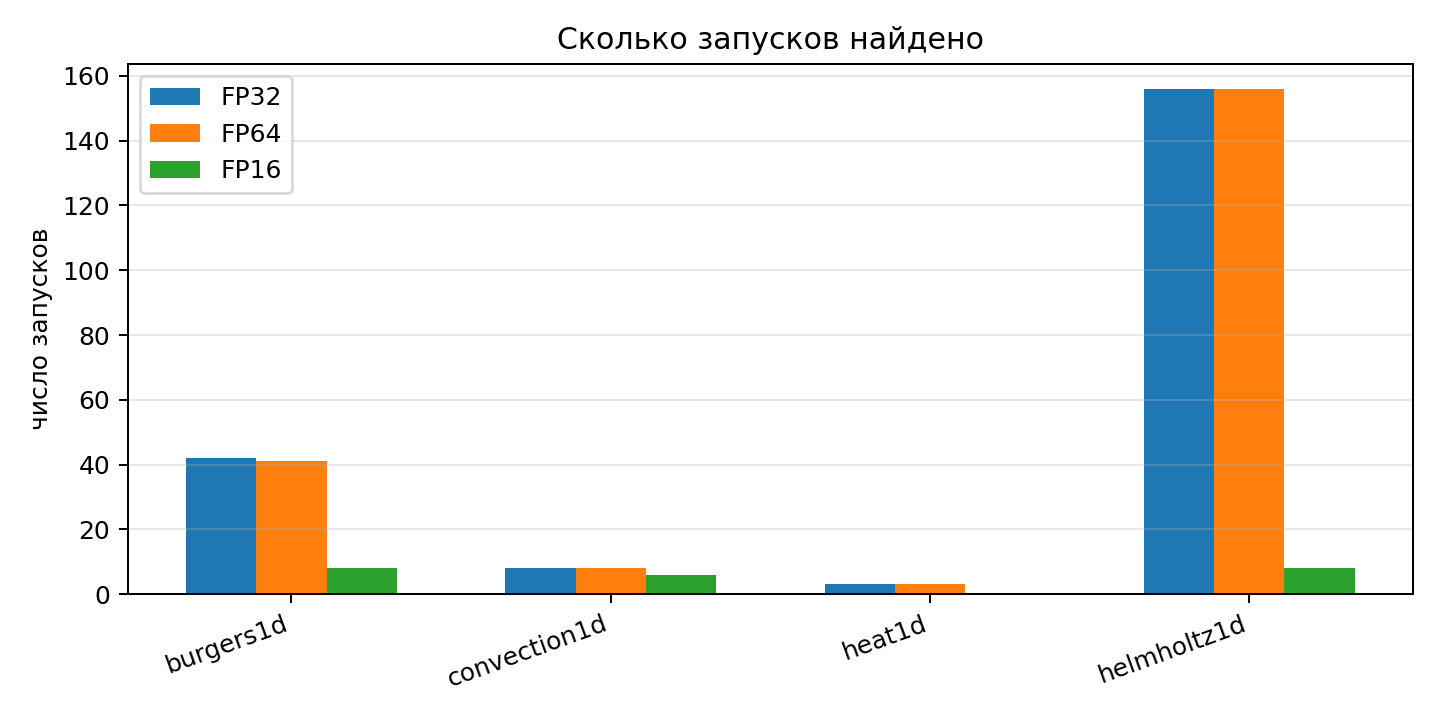

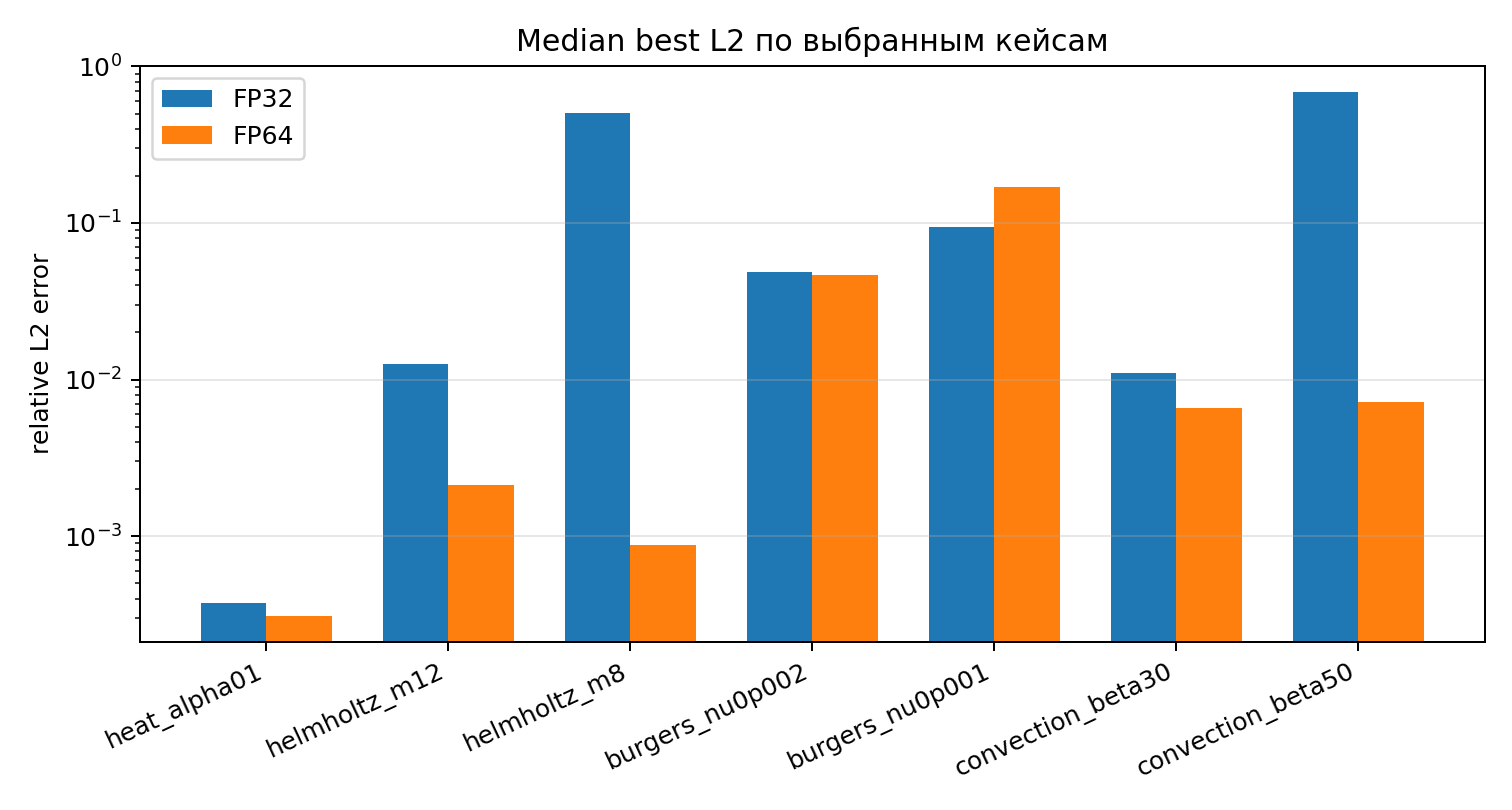

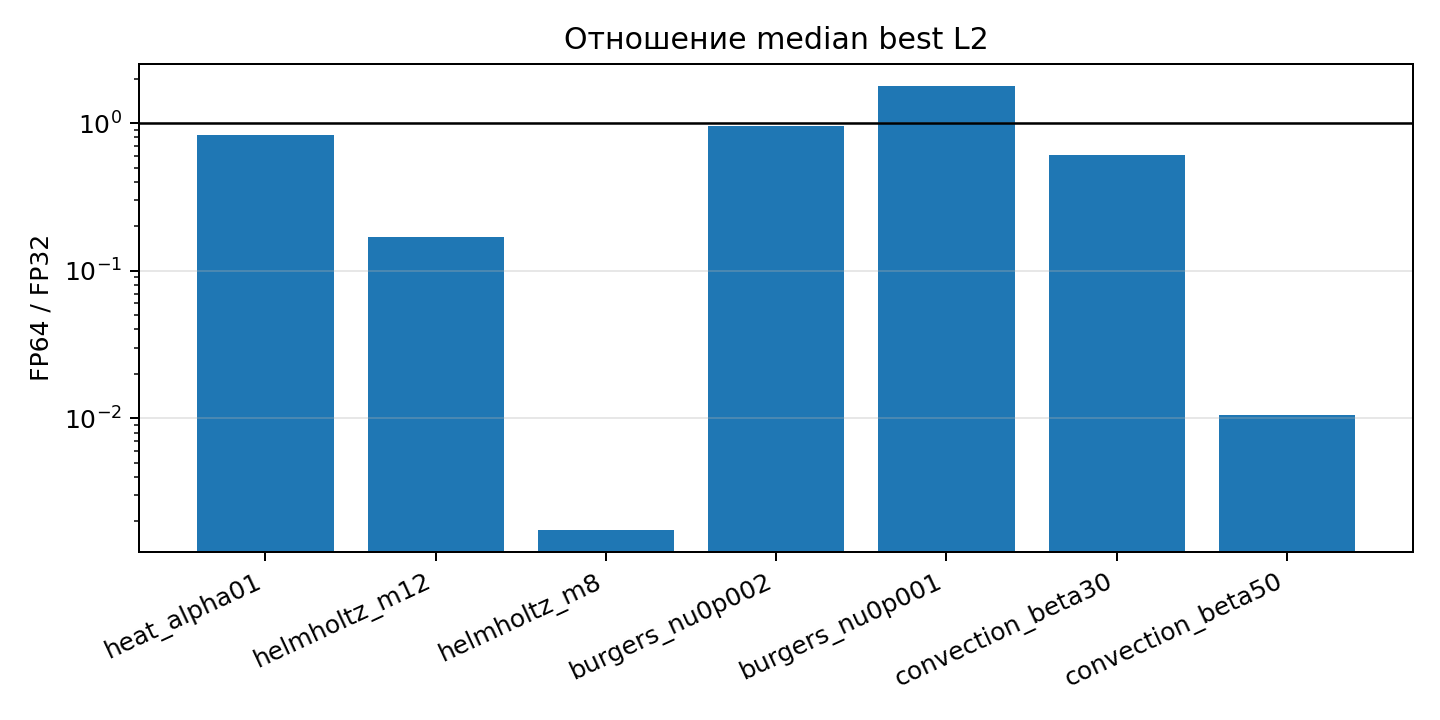

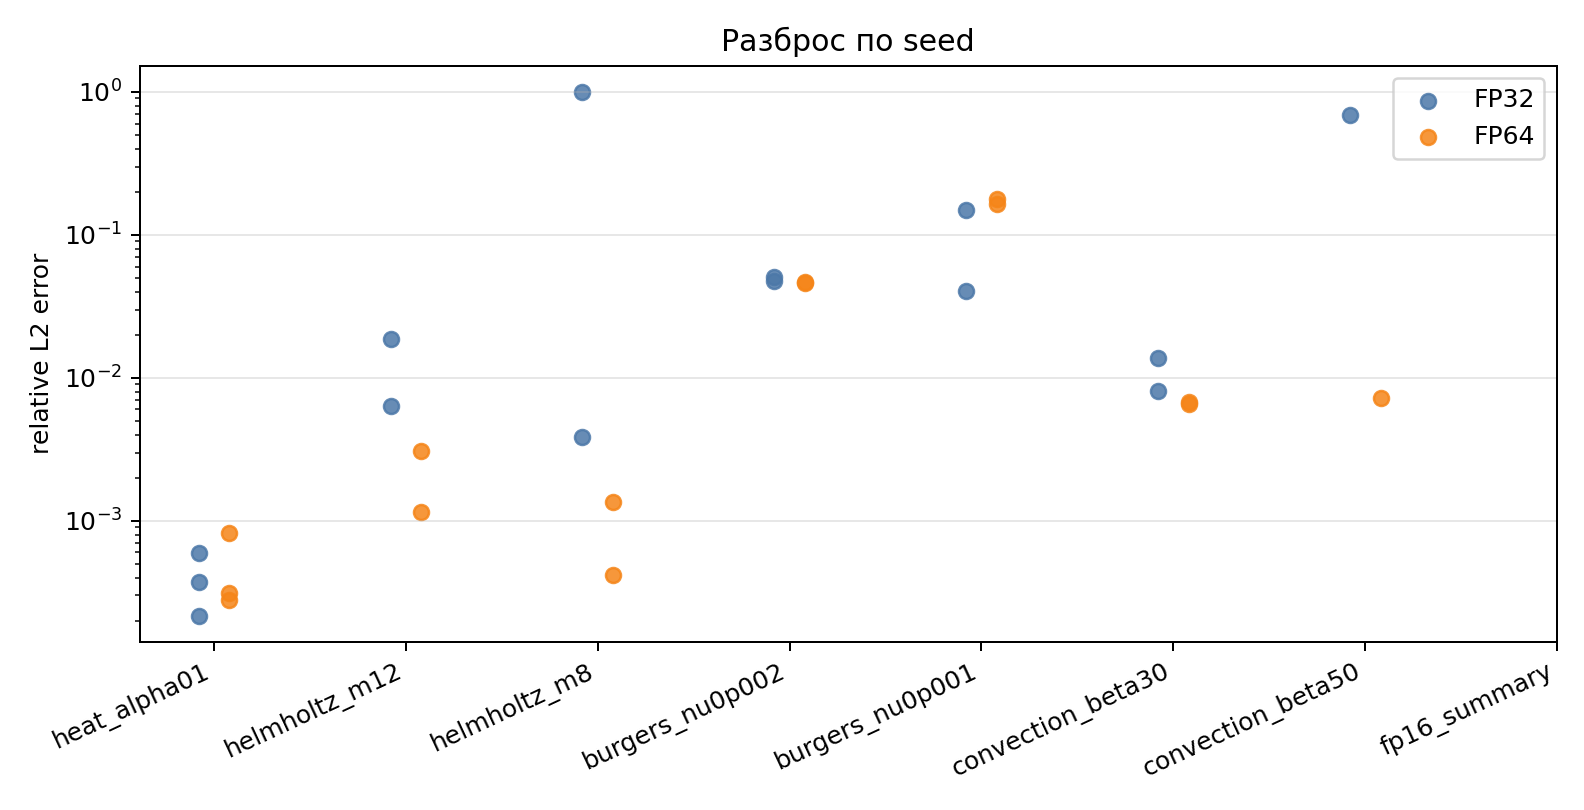

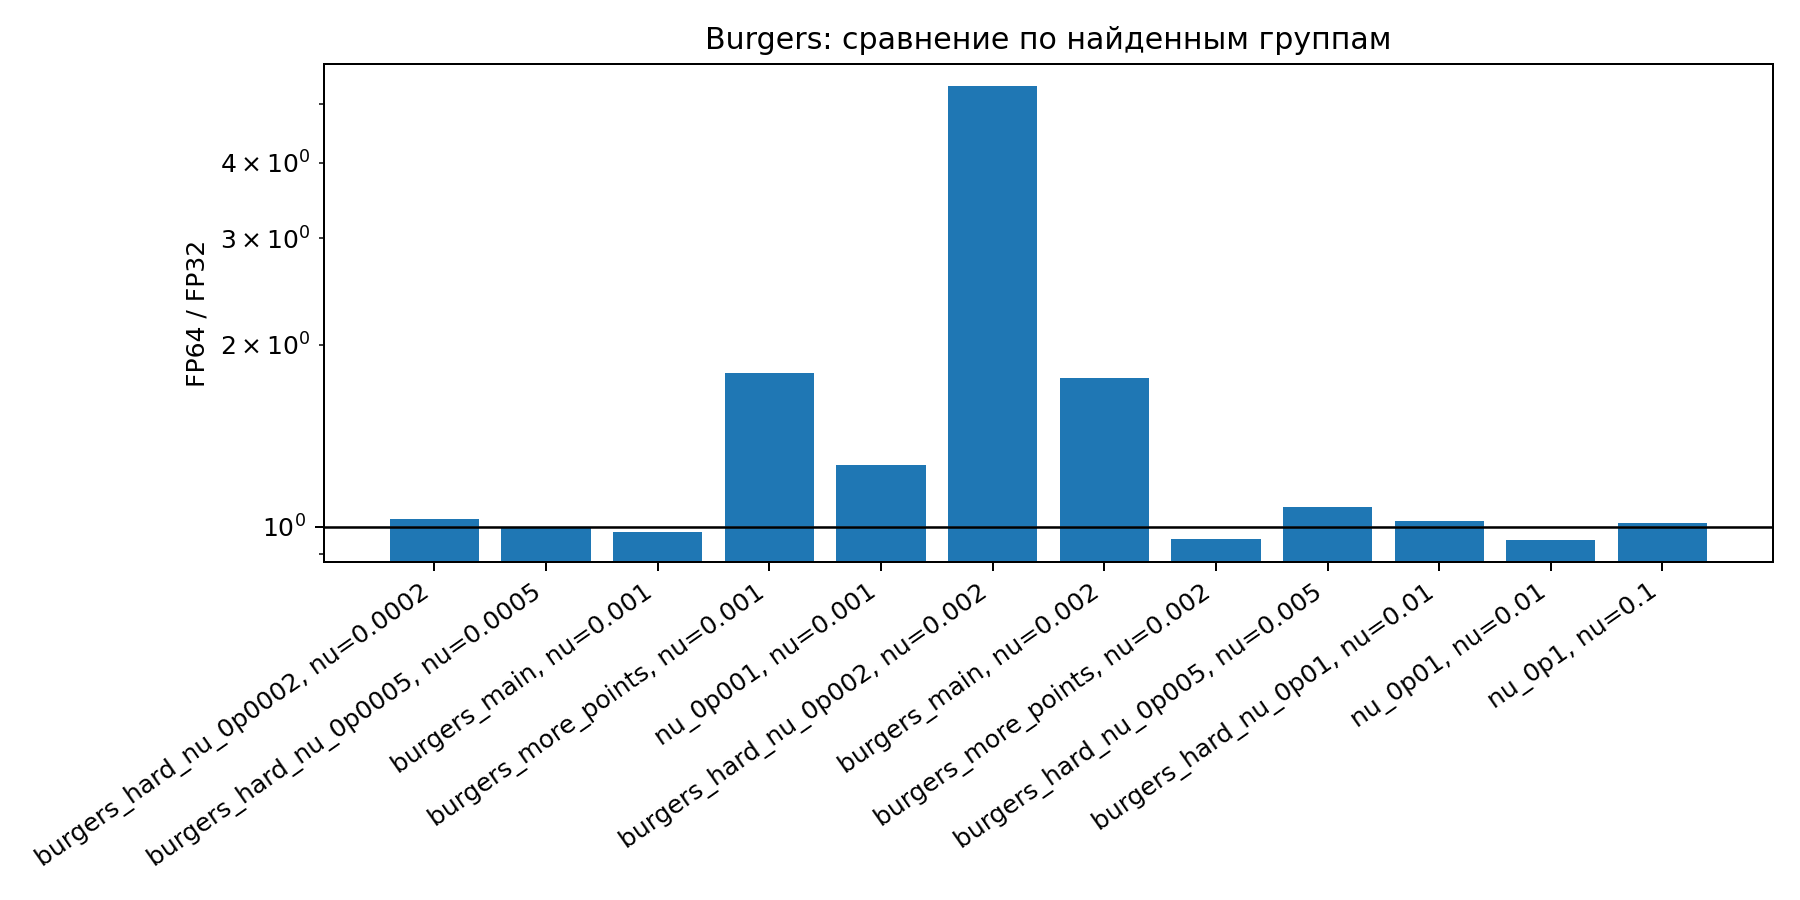

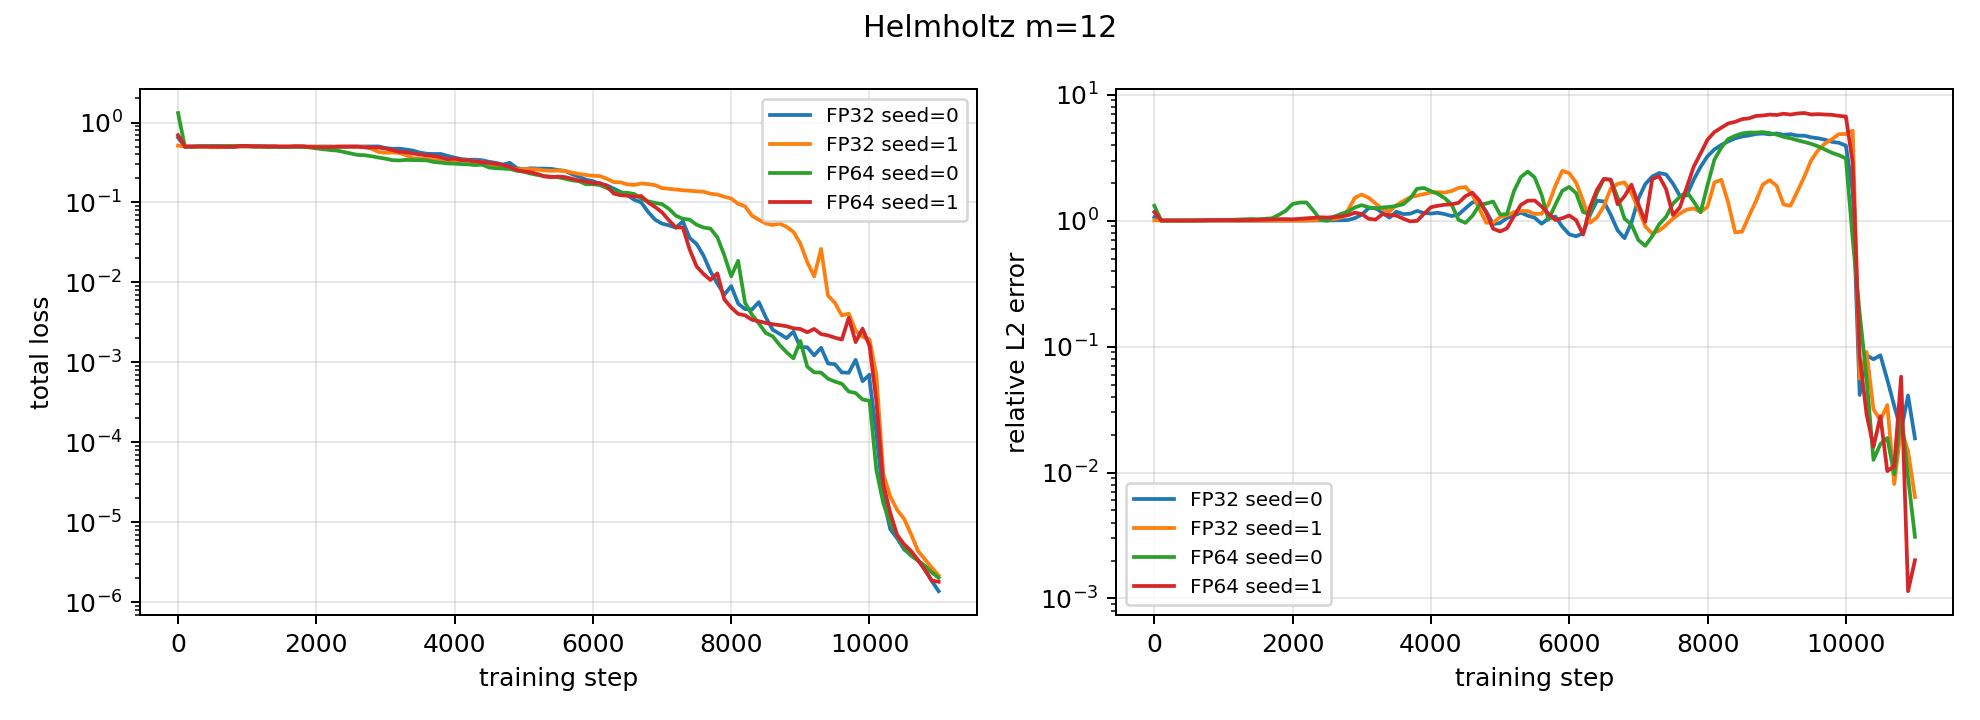

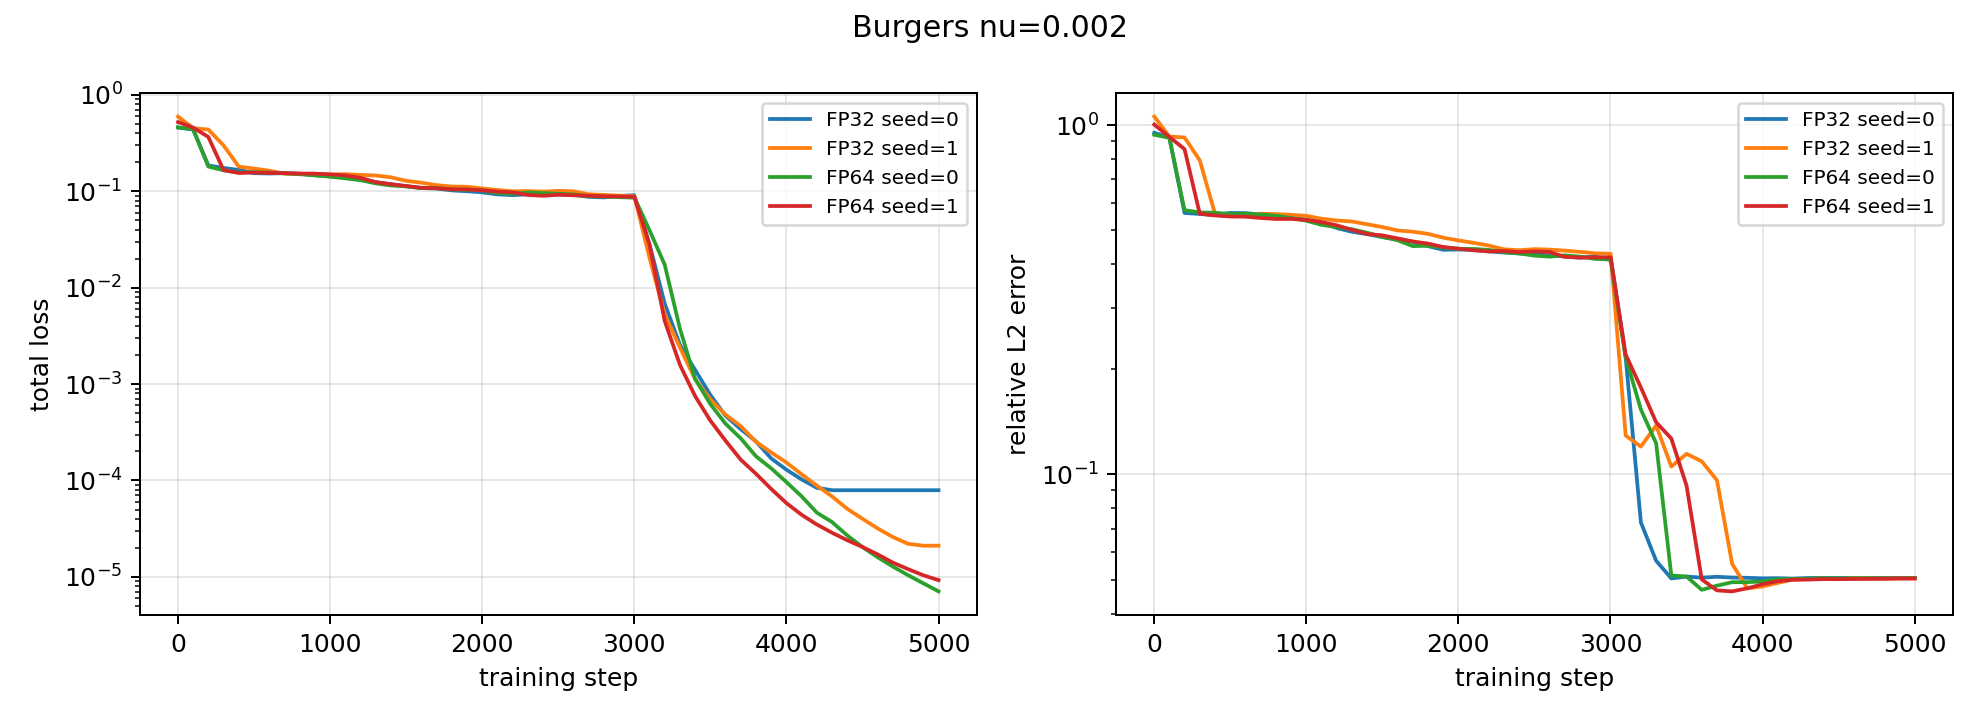

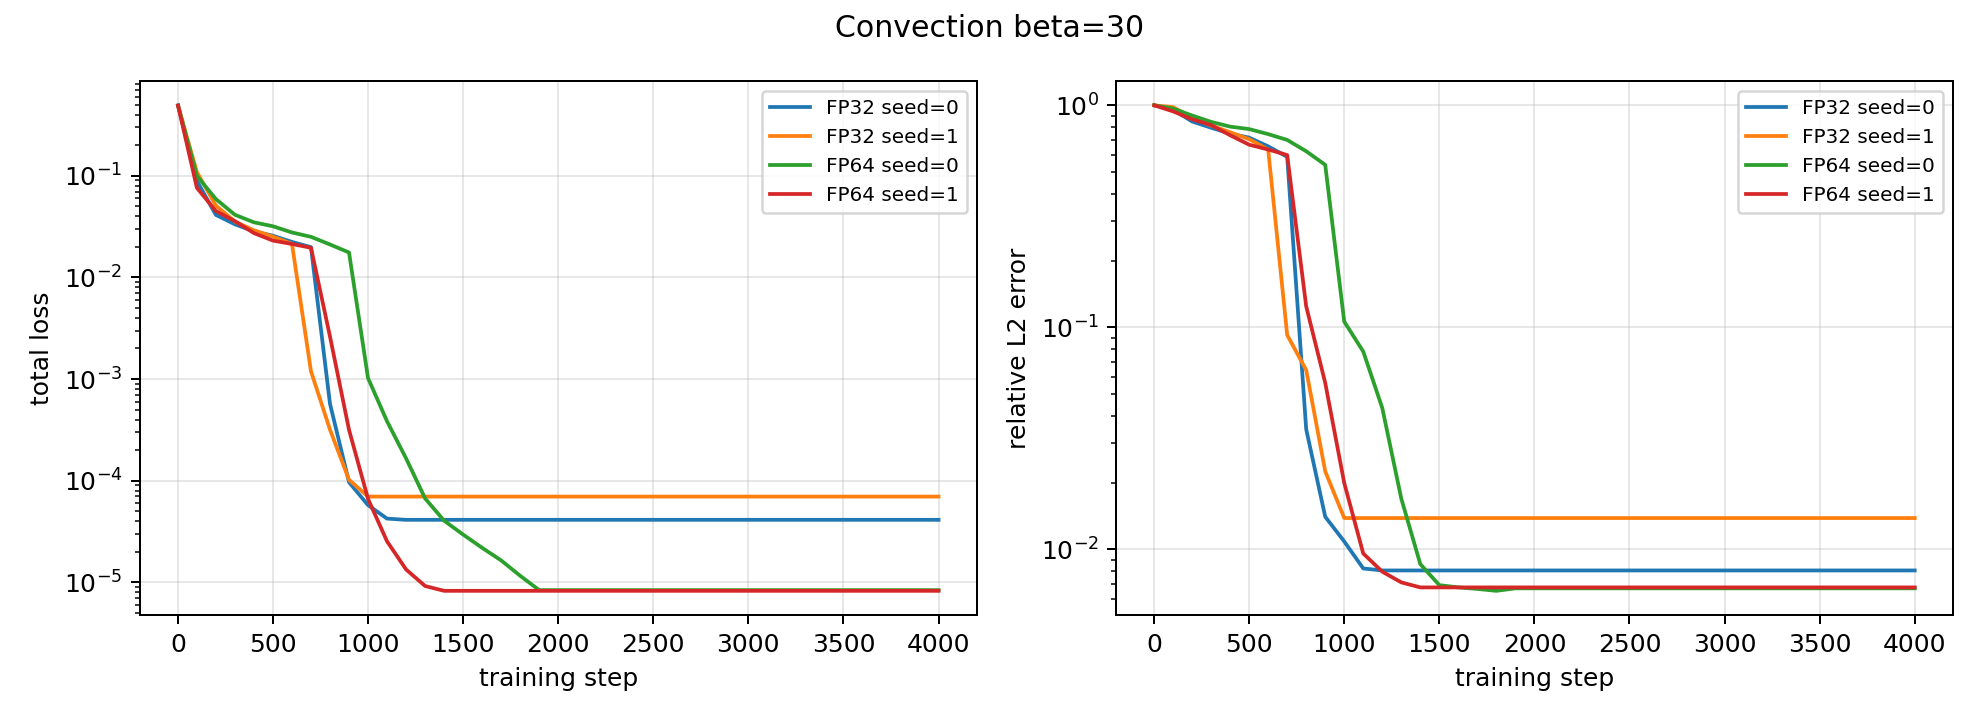

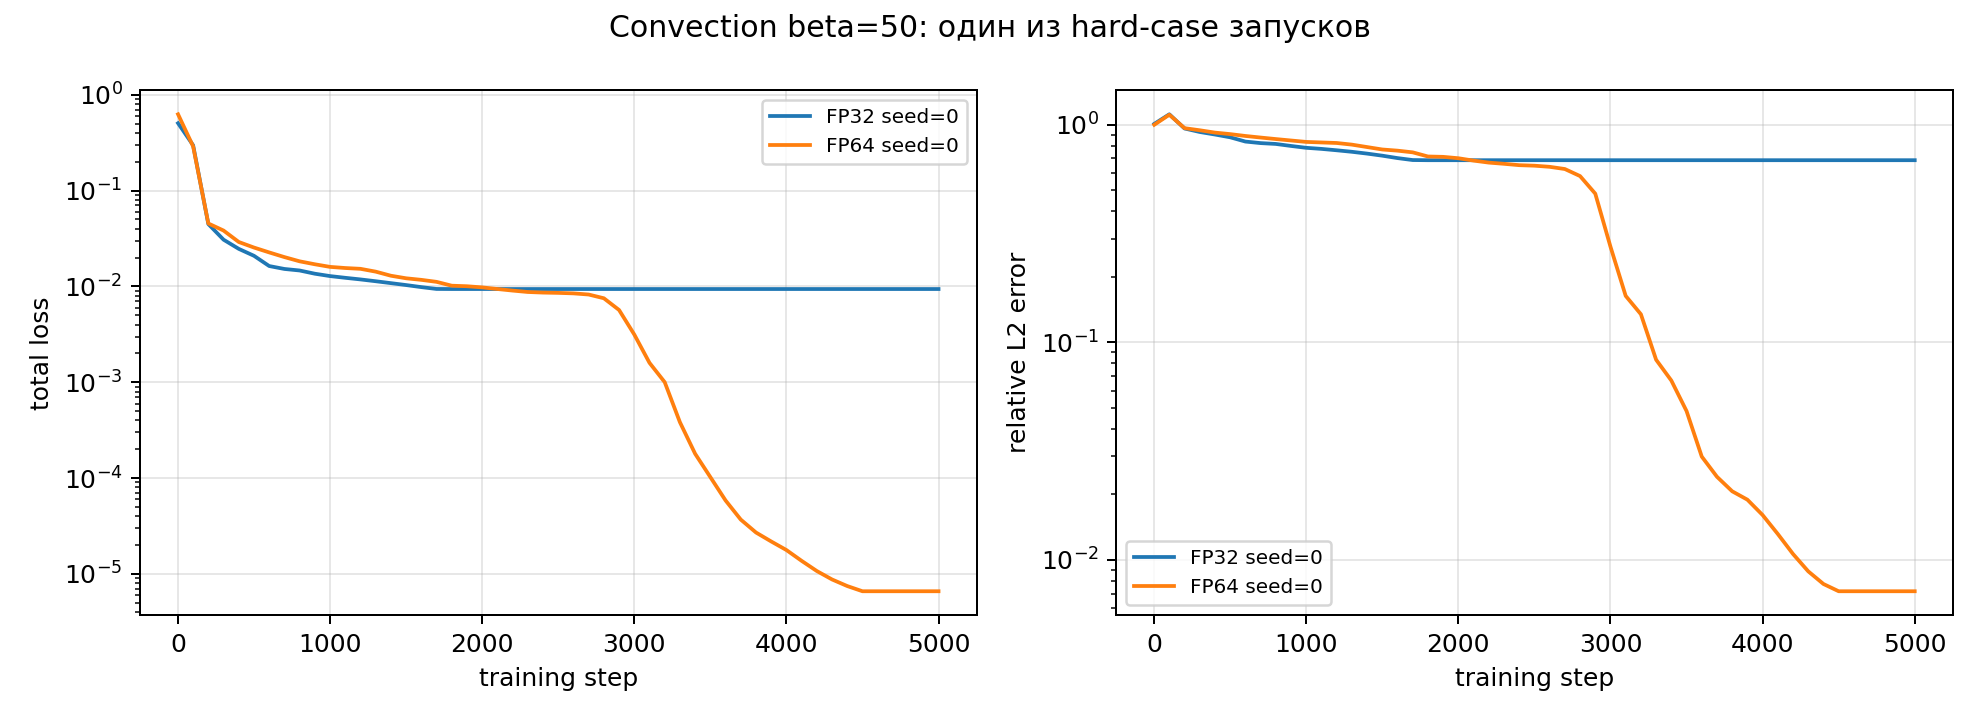

In [25]:
for name in [
    "report_task_overview.png",
    "report_best_l2_by_dtype.png",
    "report_fp64_fp32_ratio.png",
    "report_seed_scatter.png",
    "report_burgers_summary.png",
    "report_helmholtz_m12_curves.png",
    "report_burgers_nu0002_curves.png",
    "report_convection_beta30_curves.png",
    "report_convection_beta50_check.png",
]:
    path = fig_dir / name
    if path.exists():
        display(Image(filename=str(path)))

На графиках видно, что Helmholtz m=12 - самый чистый положительный пример для FP64. Burgers остаётся смешанным. Convection beta=50 лучше показывать отдельно как кейс, который требует проверки на дополнительных seed.

## 9. Что можно проверить дополнительно

Полный перезапуск не нужен. Ниже только небольшой план для Convection beta=50.

In [26]:
text = (rerun_dir / "optional_checks.md").read_text()
display(Markdown(text))

# Дополнительные проверки

Основные таблицы уже собраны из существующих логов. Полный перезапуск экспериментов не нужен.
Ниже только небольшие проверки, которые можно сделать, если нужно усилить отдельные места в отчёте.

## Что уже есть

- таблицы по всем найденным run-папкам;
- сравнение FP32 и FP64 по медиане и bad rate;
- отдельный блок по FP16;
- графики для основных кейсов;
- осторожная пометка для Convection beta=50.

## Что можно проверить дополнительно

- Convection beta=50 на seed 1 и 2 для FP32/FP64;
- MAE/RMSE и карты exact / prediction / error для Convection beta=50, если нужны картинки в отчёт;
- один FP16-запуск можно оставить только как иллюстрацию нестабильности.

## Почему не нужен полный перезапуск

В логах уже есть Heat, Burgers, Helmholtz и Convection с разными параметрами. Проблема не в объёме данных, а в том, что часть кейсов seed-sensitive.

## Минимальные selected checks

- convection_beta50_fp32_seed1
- convection_beta50_fp32_seed2
- convection_beta50_fp64_seed1
- convection_beta50_fp64_seed2

Если нужны карты для уже выбранного seed 0:

- convection_beta50_fp32_seed0
- convection_beta50_fp64_seed0

FP16 check можно запускать отдельно, но он не обязателен для основного сравнения FP32/FP64.
